In [ ]:
!pip install openpyxl

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
!wget https://archive.ics.uci.edu/static/public/352/online+retail.zip

--2025-09-12 12:54:27--  https://archive.ics.uci.edu/static/public/352/online+retail.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘online+retail.zip.1’

online+retail.zip.1     [    <=>             ]  22.62M  31.6MB/s    in 0.7s    

2025-09-12 12:54:28 (31.6 MB/s) - ‘online+retail.zip.1’ saved [23715478]



In [ ]:
!unzip online+retail.zip

Archive:  online+retail.zip
replace Online Retail.xlsx? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
df1=pd.read_excel('Online Retail.xlsx',dtype={'InvoiceNo':'string','StockCode':'string','Description':'string','Country':'string'})
df1.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [ ]:
df1.shape

(541909, 8)

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  string        
 1   StockCode    541909 non-null  string        
 2   Description  540455 non-null  string        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  string        
dtypes: datetime64[ns](1), float64(2), int64(1), string(4)
memory usage: 33.1 MB


In [ ]:
df1[df1.Description.isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,<NA>,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,<NA>,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,<NA>,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,<NA>,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,<NA>,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,<NA>,-2,2011-12-07 18:26:00,0.0,NaN,United Kingdom
535326,581203,23406,<NA>,15,2011-12-07 18:31:00,0.0,NaN,United Kingdom
535332,581209,21620,<NA>,6,2011-12-07 18:35:00,0.0,NaN,United Kingdom
536981,581234,72817,<NA>,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom


In [ ]:
most_freq =df1[["StockCode","Description"]].value_counts().reset_index()
most_freq

,StockCode,Description,count
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2302
1,22423,REGENCY CAKESTAND 3 TIER,2200
2,85099B,JUMBO BAG RED RETROSPOT,2159
3,47566,PARTY BUNTING,1727
4,20725,LUNCH BAG RED RETROSPOT,1638
...,...,...,...
4787,35833P,check,1
4788,21410,COUNTRY COTTAGE DOORSTOP GREEN,1
4789,21412,VINTAGE GOLD TINSEL REEL,1
4790,21414,SCALLOP SHELL SOAP DISH,1


In [ ]:
most_freq[most_freq.StockCode=="85123A"].head(1) #multiple descriptions with one stockcode but we picked the mode

,StockCode,Description,count
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2302


In [ ]:
most_freq=most_freq.groupby("StockCode").head(1)
most_freq

,StockCode,Description,count
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2302
1,22423,REGENCY CAKESTAND 3 TIER,2200
2,85099B,JUMBO BAG RED RETROSPOT,2159
3,47566,PARTY BUNTING,1727
4,20725,LUNCH BAG RED RETROSPOT,1638
...,...,...,...
4784,35832,WOOLLY HAT SOCK GLOVE ADVENT STRING,1
4785,35833G,4 GOLD FLOCK CHRISTMAS BALLS,1
4788,21410,COUNTRY COTTAGE DOORSTOP GREEN,1
4789,21412,VINTAGE GOLD TINSEL REEL,1


In [ ]:
most_freq.columns=["StockCode","freq_description","count"]
df2=df1.merge(most_freq,on="StockCode",how="left")
df2.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,freq_description,count
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,WHITE HANGING HEART T-LIGHT HOLDER,2302.0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,WHITE METAL LANTERN,328.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,CREAM CUPID HEARTS COAT HANGER,293.0


In [ ]:
df2[df2.Description.isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,freq_description,count
622,536414,22139,<NA>,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom,RETROSPOT TEA SET CERAMIC 11 PC,988.0
1970,536545,21134,<NA>,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom,<NA>,NaN
1971,536546,22145,<NA>,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,CHRISTMAS CRAFT HEART STOCKING,1.0
1972,536547,37509,<NA>,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,NEW ENGLAND MUG W GIFT BOX,2.0
1987,536549,85226A,<NA>,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,<NA>,NaN


In [ ]:
df2["Description"]=df2["freq_description"]  #lets replace description with its most frequent attached to a stockcode
df2.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,freq_description,count
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,WHITE HANGING HEART T-LIGHT HOLDER,2302.0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,WHITE METAL LANTERN,328.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,CREAM CUPID HEARTS COAT HANGER,293.0


In [ ]:
df2.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,112
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0
freq_description,112
count,112


In [ ]:
df2.dropna(subset=['Description'],inplace=True)
df2.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,134968
Country,0
freq_description,0
count,0


In [ ]:
df2[df2.CustomerID.isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,freq_description,count
622,536414,22139,RETROSPOT TEA SET CERAMIC 11 PC,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom,RETROSPOT TEA SET CERAMIC 11 PC,988.0
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom,DECORATIVE ROSE BATHROOM BOTTLE,164.0
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom,DECORATIVE CATS BATHROOM BOTTLE,188.0
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom,POLKADOT RAIN HAT,236.0
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom,RAIN PONCHO RETROSPOT,252.0


In [ ]:
df2.drop(columns=["freq_description","count"],inplace=True)
df2.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [ ]:
df2.describe() #lets handle unnecesarry negative numbers

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541797.000000,541797,541797.000000,406829.000000
mean,9.555919,2011-07-04 14:06:48.671255296,4.612067,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:36:00,1.250000,13953.000000
50%,3.000000,2011-07-20 08:59:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:41:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.103428,NaN,96.769831,1713.600303


In [ ]:
df2[df2.Quantity<0].head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [ ]:
df3=df2[(df2.Quantity>0)&(df2.UnitPrice>0)]
df3.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,530104.000000,530104,530104.000000,397884.000000
mean,10.542037,2011-07-04 20:16:05.225087744,3.907625,15294.423453
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,1.000000,2011-03-28 12:22:00,1.250000,13969.000000
50%,3.000000,2011-07-20 12:58:00,2.080000,15159.000000
75%,10.000000,2011-10-19 12:39:00,4.130000,16795.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000
std,155.524124,NaN,35.915681,1713.141560


In [ ]:
#is the max value of quantity valid
df3.Quantity.quantile(0.9999)
#what!!! ahh 99.99% are less than 1500 be conscious

np.float64(1439.8763999990188)

**Feature Engineering:Create New Columns**

In [ ]:
df4=df3.copy()
df4["TotalPrice"]=df4["Quantity"]*df4["UnitPrice"]
df4.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00


In [ ]:
df4['Month']=df4['InvoiceDate'].dt.month
df4.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12


1.Plot Monthly Sales

In [ ]:
monthly_sales=df4.groupby("Month")

In [ ]:
for title,data in monthly_sales:
  print(title)
  print(data.head(3))

1
      InvoiceNo StockCode              Description  Quantity  \
42481    539993     22386  JUMBO BAG PINK POLKADOT        10   
42482    539993     21499       BLUE POLKADOT WRAP        25   
42483    539993     21498      RED RETROSPOT WRAP         25   

              InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  \
42481 2011-01-04 10:00:00       1.95     13313.0  United Kingdom        19.5   
42482 2011-01-04 10:00:00       0.42     13313.0  United Kingdom        10.5   
42483 2011-01-04 10:00:00       0.42     13313.0  United Kingdom        10.5   

       Month  
42481      1  
42482      1  
42483      1  
2
      InvoiceNo StockCode                     Description  Quantity  \
77628    542776     21671    RED SPOT CERAMIC DRAWER KNOB        48   
77629    542776     21668  RED STRIPE CERAMIC DRAWER KNOB        12   
77630    542776     21670   BLUE SPOT CERAMIC DRAWER KNOB        12   

              InvoiceDate  UnitPrice  CustomerID         Country  TotalPr

In [ ]:
monthly_sales=monthly_sales.TotalPrice.sum()

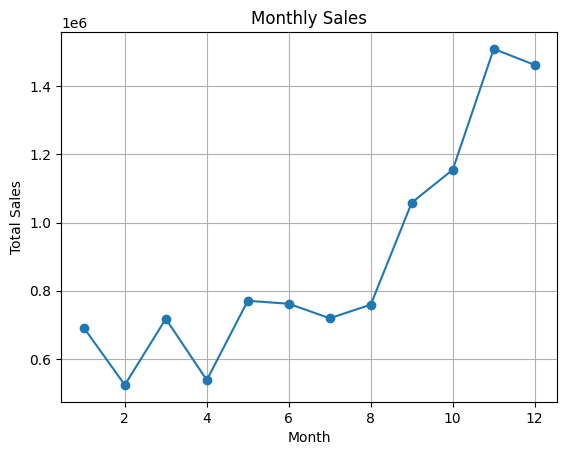

In [ ]:
monthly_sales.plot(kind="line",title="Monthly Sales",marker="o")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid()
plt.show()

**Insights**

 Total Sales started rising after August having a peak in November. This is likely due to the holiday Season at the end of the year

2. Top 5 countries by sales

In [ ]:
countries=df4.groupby("Country")

In [ ]:
countries=countries.TotalPrice.sum().sort_values(ascending=False).head(5)
countries

,TotalPrice
Country,
United Kingdom,9025222.084
Netherlands,285446.340
EIRE,283453.960
Germany,228867.140
France,209715.110


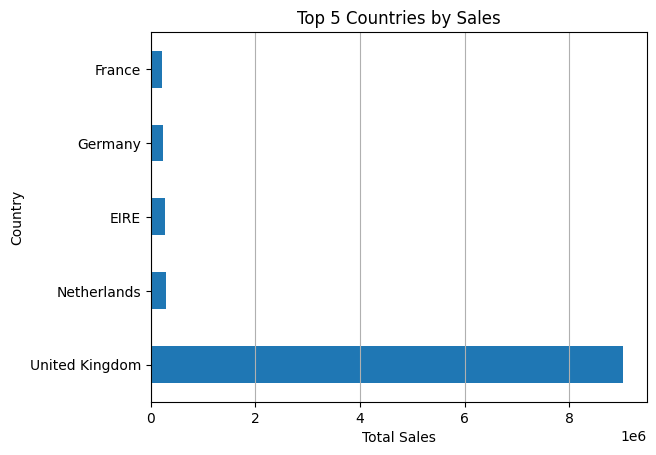

In [ ]:
countries.plot(kind="barh",title="Top 5 Countries by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Country")
plt.grid(axis="x")
plt.show()

Country
United Kingdom    89.958016
Netherlands        2.845158
EIRE               2.825300
Germany            2.281211
France             2.090315
Name: TotalPrice, dtype: float64


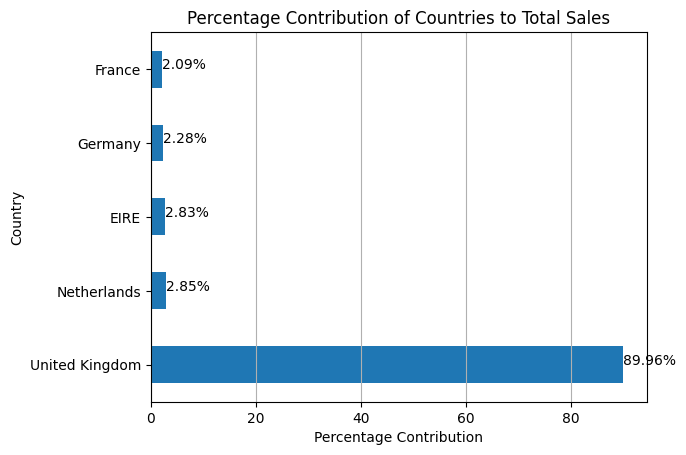

In [ ]:
total_sales = countries.sum()
country_percentage = (countries / total_sales) * 100
print(country_percentage)
ax = country_percentage.plot(kind="barh", title="Percentage Contribution of Countries to Total Sales")
plt.xlabel("Percentage Contribution")
plt.ylabel("Country")
plt.grid(axis="x")

# Add percentage labels to the bars
for index, value in enumerate(country_percentage):
    ax.text(value, index, f'{value:.2f}%',fontsize=10)

plt.show()

In [ ]:
productWise=df4.groupby("StockCode").TotalPrice.sum()
top_5_products=productWise.sort_values(ascending=False).head()

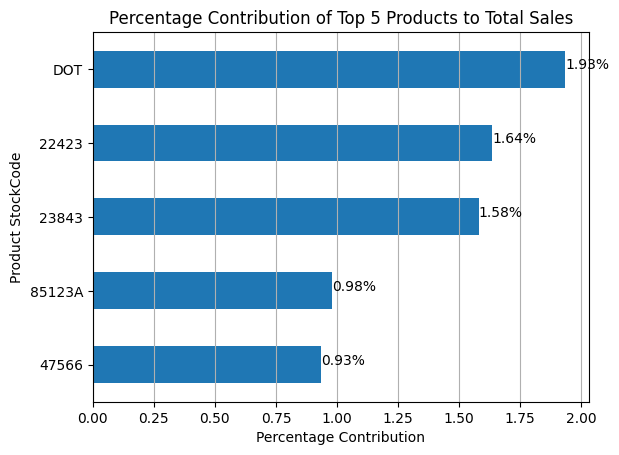

In [ ]:
total_sales_products = productWise.sum()
product_percentage = (top_5_products / total_sales_products) * 100

ax = product_percentage.plot(kind="barh", title="Percentage Contribution of Top 5 Products to Total Sales")
plt.xlabel("Percentage Contribution")
plt.ylabel("Product StockCode")
plt.grid(axis="x")

# Add percentage labels to the bars
for index, value in enumerate(product_percentage):
    ax.text(value, index, f'{value:.2f}%')
plt.gca().invert_yaxis() #to show the highest sales at the top
plt.show()

In [ ]:
#what is dot
df4[df4.StockCode=="DOT"].head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month
1814,536544,DOT,DOTCOM POSTAGE,1,2010-12-01 14:32:00,569.77,NaN,United Kingdom,569.77,12


In [ ]:
for stock_code in top_5_products.index:
  description=df4[df4.StockCode==stock_code].Description.iloc[0]
  print(f"{stock_code}==>{description}")

DOT==>DOTCOM POSTAGE
22423==>REGENCY CAKESTAND 3 TIER
23843==>PAPER CRAFT , LITTLE BIRDIE
85123A==>WHITE HANGING HEART T-LIGHT HOLDER
47566==>PARTY BUNTING


4.RFM analysis

In [ ]:
curr_date=df4['InvoiceDate'].max() + pd.Timedelta(days=1)

In [ ]:
#analysis on customer to return recency, frequency and monetary
rfm_df=df4.groupby("CustomerID").agg({
    "InvoiceDate":lambda date:(curr_date-date.max()).days,
    "InvoiceNo":"count",
    "TotalPrice":"sum"
})
rfm_df.columns=["Recency","Frequency","Monetary"]
rfm_df.sort_values("Recency",ascending=False).head()

,Recency,Frequency,Monetary
CustomerID,,,
18074.0,374,13,489.60
12791.0,374,2,192.60
16583.0,374,14,233.45
17908.0,374,58,243.28
17968.0,374,85,277.35


In [ ]:
df4[df4.CustomerID==18074].iloc[0:5,0:]
days_max=curr_date-df4[df4.CustomerID==18074].InvoiceDate.max()
days_max.days
if(days_max.days>=374):
  print("yes it don tay wey the guy patronised us ooo")

yes it don tay wey the guy patronised us ooo


In [ ]:
#segment customers based on rfm
rfm_df["R_segment"]=pd.qcut(rfm_df["Recency"],q=5,labels=[5,4,3,2,1])
rfm_df["F_segment"]=pd.qcut(rfm_df["Frequency"],q=5,labels=[1,2,3,4,5])
rfm_df["M_segment"]=pd.qcut(rfm_df["Monetary"],q=5,labels=[1,2,3,4,5])
#lets add the three columns to get the score
rfm_df['RFM_Score']=rfm_df[['R_segment', 'F_segment', 'M_segment']].sum(axis=1)
rfm_df.sort_values("RFM_Score",ascending=False).head() #top 5 performer

,Recency,Frequency,Monetary,R_segment,F_segment,M_segment,RFM_Score
CustomerID,,,,,,,
15061.0,4,403,54534.14,5,5,5,15
12417.0,3,192,3649.10,5,5,5,15
14146.0,9,210,4191.00,5,5,5,15
18245.0,7,175,2567.06,5,5,5,15
14135.0,2,134,4690.31,5,5,5,15


In [ ]:
rfm_df.reset_index(inplace=True)

In [ ]:
#number of clients in top countries
df4.groupby("Country").CustomerID.nunique().sort_values(ascending=False)

,CustomerID
Country,
United Kingdom,3920
Germany,94
France,87
Spain,30
Belgium,25
Switzerland,21
Portugal,19
Italy,14
Finland,12


5.Customer Churn Analysis

In [ ]:
df4.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12


In [ ]:
customer_id_recency=df4.groupby("CustomerID").InvoiceDate.max().reset_index()
customer_id_recency.head()

,CustomerID,InvoiceDate
0,12346.0,2011-01-18 10:01:00
1,12347.0,2011-12-07 15:52:00
2,12348.0,2011-09-25 13:13:00
3,12349.0,2011-11-21 09:51:00
4,12350.0,2011-02-02 16:01:00


In [ ]:
customer_id_recency["Days_since_last_purchase"]=(curr_date-customer_id_recency["InvoiceDate"]).dt.days
customer_id_recency.head()

,CustomerID,InvoiceDate,Days_since_last_purchase
0,12346.0,2011-01-18 10:01:00,326
1,12347.0,2011-12-07 15:52:00,2
2,12348.0,2011-09-25 13:13:00,75
3,12349.0,2011-11-21 09:51:00,19
4,12350.0,2011-02-02 16:01:00,310


In [ ]:
#define churn threshold
churn_threshold=customer_id_recency["Days_since_last_purchase"].mean()
churn_threshold=churn_threshold.round(2)

In [ ]:
churned_customers=customer_id_recency[customer_id_recency["Days_since_last_purchase"]>=churn_threshold]
churned_customers.head()

,CustomerID,InvoiceDate,Days_since_last_purchase
0,12346.0,2011-01-18 10:01:00,326
4,12350.0,2011-02-02 16:01:00,310
6,12353.0,2011-05-19 17:47:00,204
7,12354.0,2011-04-21 13:11:00,232
8,12355.0,2011-05-09 13:49:00,214


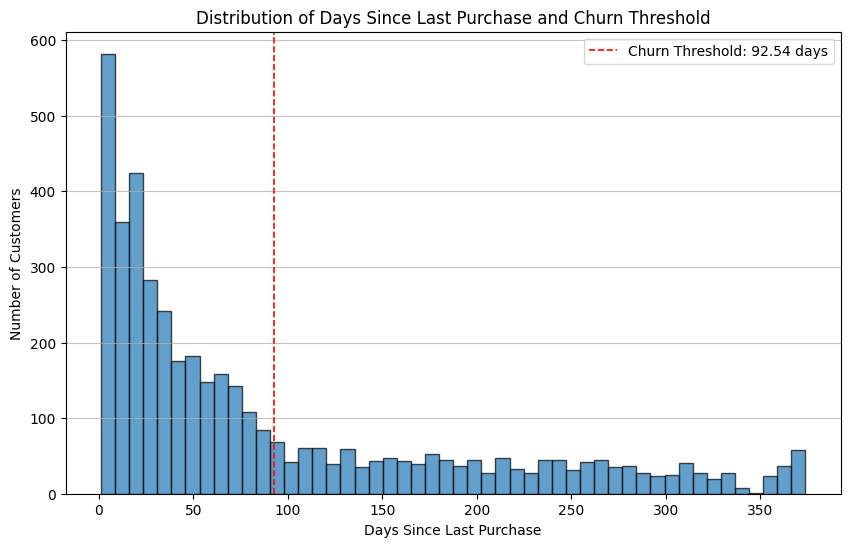

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(customer_id_recency['Days_since_last_purchase'], bins=50, edgecolor='k', alpha=0.7)
plt.axvline(churn_threshold, color='red', linestyle='dashed', linewidth=1.2, label=f'Churn Threshold: {churn_threshold} days')
plt.title('Distribution of Days Since Last Purchase and Churn Threshold')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Number of Customers')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()